In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import jax 
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import Ball, Stick, Zeppelin, Dti, BallStick, Ball2Stick


ball_stick = Ball2Stick.from_theta(np.random.randn(Ball2Stick.theta_dim))

In [8]:
bvals = np.linspace(10, 2000, 200)
bvecs = jax.random.normal(jax.random.PRNGKey(0), shape=(200, 3))
bvecs = bvecs / jnp.linalg.norm(bvecs, axis=-1, keepdims=True)

@jax.jit
def simulator(rng):
    rng1, rng2 = jax.random.split(rng)
    theta = jax.random.normal(rng1, shape=(Ball2Stick.theta_dim,))
    model_mask = jax.random.bernoulli(rng2, p=0.6, shape=(3,))
    #model_mask = jnp.array([True, True, False])
    ball_stick = Ball2Stick.from_theta(theta, model_mask=model_mask)
    
    x_o = ball_stick.signal(bvals, bvecs)
    return model_mask, theta, x_o
    

In [4]:
# from dmri.utils.transform import normal_to_dirichlet

# normal_to_dirichlet(jnp.ones(3), jax.random.normal(jax.random.PRNGKey(0), shape=(2,)), mask=jnp.array([True, False, True]))

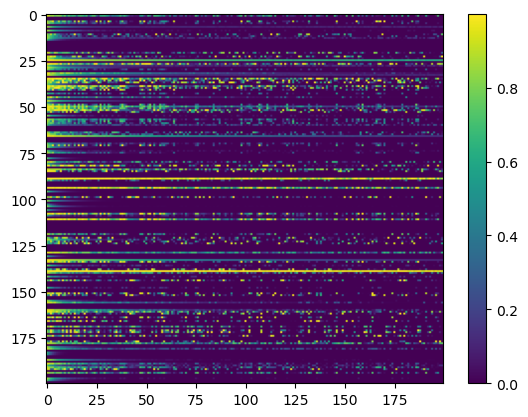

In [5]:
_, _, x_o, frac = jax.vmap(simulator)(jax.random.split(jax.random.PRNGKey(0), num=200))

plt.imshow(x_o, aspect='auto')
plt.colorbar()

In [1]:
from dmri.nn.tokenizer import StructuredTokenizer
from dmri.nn.autoregressive import ModelIdentificationDecoder
from flax import nnx

# #tokenizer = StructuredTokenizer(dims_per_component, rngs=nnx.Rngs(0))
# model = ModelIdentificationDecoder(rngs=nnx.Rngs(1), context_dim=200, widening_factor=3, num_layers=2)
# params = nnx.state(model, nnx.Param)

In [ ]:
nnx.initializers.orthogonal

In [2]:
?nnx.Embed

Init signature: nnx.Embed(*args: 'Any', **kwargs: 'Any') -> 'Any'
Docstring:     
Embedding Module.

Example usage::

  >>> from flax import nnx
  >>> import jax.numpy as jnp

  >>> layer = nnx.Embed(num_embeddings=5, features=3, rngs=nnx.Rngs(0))
  >>> nnx.state(layer)
  State({
    'embedding': VariableState(
      type=Param,
      value=Array([[-0.90411377, -0.3648777 , -1.1083648 ],
             [ 0.01070483,  0.27923733,  1.7487359 ],
             [ 0.59161806,  0.8660184 ,  1.2838588 ],
             [-0.748139  , -0.15856352,  0.06061118],
             [-0.4769059 , -0.6607095 ,  0.46697947]], dtype=float32)
    )
  })
  >>> # get the first three and last three embeddings
  >>> indices_input = jnp.array([[0, 1, 2], [-1, -2, -3]])
  >>> layer(indices_input)
  Array([[[-0.90411377, -0.3648777 , -1.1083648 ],
          [ 0.01070483,  0.27923733,  1.7487359 ],
          [ 0.59161806,  0.8660184 ,  1.2838588 ]],
  <BLANKLINE>
         [[-0.4769059 , -0.6607095 ,  0.46697947],
       

In [9]:
masks, thetas, x_os = jax.vmap(simulator)(jax.random.split(jax.random.PRNGKey(1), 10))

model(masks, context=x_os)

Array([[ 0.753, -0.116,  0.174],
       [ 0.   ,  0.43 ,  0.574],
       [ 0.636, -0.436,  1.522],
       [ 0.   ,  1.487,  1.503],
       [ 0.   ,  0.43 ,  0.574],
       [ 0.   ,  0.43 ,  0.574],
       [ 0.499,  0.046,  1.183],
       [ 0.205, -0.006,  1.312],
       [ 0.97 ,  0.721,  0.823],
       [ 0.   ,  1.487,  0.365]], dtype=float32)

In [10]:
import optax

scheduler = optax.cosine_decay_schedule(1e-3, 20*500)
optimizer = optax.chain(optax.adaptive_grad_clip(50.), optax.adamw(scheduler))

opt_state = optimizer.init(params)


def loss_fn(params, data, rng):
    nnx.update(model, params)
    components, thetas, xs = data

    logits = model(components, context=xs)

    loss =  optax.sigmoid_binary_cross_entropy(logits, components).sum()

    return loss

@jax.jit
def update(params, opt_state, data, rng):
    loss, grads = jax.value_and_grad(loss_fn)(params, data, rng)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state, loss

In [11]:
batch_simulator = jax.jit(jax.vmap(simulator))

In [12]:
%%timeit
batch_simulator(jax.random.split(jax.random.PRNGKey(1), 128))

292 ms ± 12.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [13]:
key = jax.random.PRNGKey(2)
for i in range(20):
    key, subkey1 = jax.random.split(key, 2) 
    masks, thetas, x_os = batch_simulator(jax.random.split(subkey1, 2**15))
    l = 0
    for j in range(500):
        key, subkey2 = jax.random.split(key, 2) 
        idx = jax.random.randint(subkey2, (512,), 0, 2**15)
        masks_batch, thetas_batch, x_os_batch = masks[idx], thetas[idx], x_os[idx]
        params, opt_state, loss = update(params, opt_state, (masks_batch, thetas_batch, x_os_batch), subkey2)
        l += loss
    print(l/500) 

543.02704
451.53024
439.4161
442.66837
439.3689
429.46744
428.45856
425.5624
425.6712
417.11377


KeyboardInterrupt: 

In [14]:
nnx.update(model, params)

In [15]:
masks[12]

Array([False,  True, False], dtype=bool)

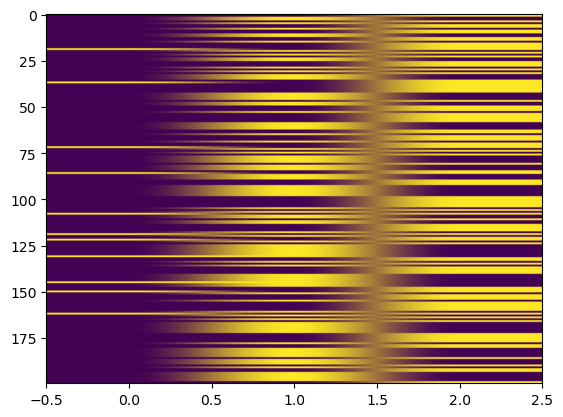

In [16]:
samples = jax.vmap(lambda k: model.sample(k, x_os[12],3))(jax.random.split(jax.random.PRNGKey(0), 200))
plt.imshow(samples, aspect='auto', vmin=0, vmax=1)